<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/03_quantvesting_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting

## End-to-End Run

The notebook is a thin client of the Quantvesting engine.

In [1]:
!pip install -q ta pyxirr matplotlib


In [2]:
# 1. Environment & imports

from google.colab import drive
drive.mount('/content/drive')

import sys

PROJECT = "/content/drive/My Drive/quantvesting_v3"
MARKET_DATA_DIR = PROJECT + "/market_data"
PORTFOLIO_ID = "ankit"
PORTFOLIO_DATA_DIR = PROJECT + f"/portfolio_data/{PORTFOLIO_ID}"

# Phase A controls
REFRESH_SCREENER = False   # True only when a new Screener XLSX has arrived
EOD_RUN = False            # True only for the final run of the day

sys.path.insert(0, PROJECT + "/src")

from quantvesting import (
    Quantvesting,
    load_config,
    load_market_data,
    load_portfolio_data,
    create_run_id,
    PROSPECT_DISPLAY_COLUMNS,
    PORTFOLIO_DISPLAY_COLUMNS,
)

RUN_ID = create_run_id()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 2. Load configuration and optionally refresh shared Screener data

config = load_config(
    PROJECT + "/config/strategy.yaml"
)

qv = Quantvesting(config)

if REFRESH_SCREENER:
    df_screener = qv.ingest_screener(MARKET_DATA_DIR)
    print(f"Screener CSV refreshed: {len(df_screener):,} securities")

market_data = load_market_data(MARKET_DATA_DIR)
portfolio_data = load_portfolio_data(
    PORTFOLIO_DATA_DIR,
    portfolio_id=PORTFOLIO_ID,
)


Screener CSV refreshed: 563 securities


In [4]:
# 3. Prospect analysis

df_prospects = qv.prospects(
    market_data,
    portfolio_data=portfolio_data,
    include_portfolio=True,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)

qv.display_dataframe(
    df_prospects,
    columns=PROSPECT_DISPLAY_COLUMNS,
    sort_by="CumlRnk",
    ascending=True,
)


,Symbol,FTT,Dev%_200,Dev%_PE,Spread%,Conviction,Cyclical,RSI_14,RSP,FTT%,ATH%,Gained%,CumlRnk,ROE%/PE,Criteria,Strategy,Category,InFolio
0,INFY,1972.00,-11.68,-38.91,16.11,X-LC,NC,57.0,74.31,69.66,63.56,17.96,1,2.0,X40,NTT,IT,DM
1,TCS,4230.71,-9.77,-42.64,15.01,X-LC,NC,52.0,83.68,80.27,80.27,19.02,2,3.0,X40,ATH,IT,DM
2,TMPV,600.00,-1.77,-82.76,4.48,X-LC,DC,55.0,59.03,72.54,228.53,18.38,3,47.3,XY24,NTT,AUTO,DM
3,HINDUNILVR,2922.00,-8.03,-40.89,6.25,X-LC,NC,42.0,36.81,41.52,40.93,2.08,4,1.0,XY25,NTT,FMCG,DM
4,HCLTECH,1853.42,-0.79,-11.33,12.94,X-LC,NC,69.0,92.01,36.17,36.17,32.95,5,1.1,X40,ATH,IT,DM
5,ITC,452.00,-13.08,-29.12,11.00,X-LC,NC,37.0,46.18,63.53,67.85,0.31,6,1.7,X40,NTT,FMCG,DM
6,RELIANCE,1952.00,-6.37,-6.74,7.09,X-LC,SC,51.0,55.21,48.80,20.82,4.21,7,0.4,XY25,BTT,REFINERIES,DM+SV
7,M&M,3762.88,2.38,-7.36,4.53,X-LC,DC,58.0,83.33,10.53,10.53,17.36,8,0.9,X40N,ATH,AUTO,DM
8,VBL,669.42,-7.81,-27.66,7.46,X-LC,NC,37.0,19.10,53.52,53.52,14.47,9,0.4,X40N,ATH,FMCG,DM
9,HDFCBANK,1073.00,-14.45,-28.50,12.03,X-LC,NC,33.0,6.25,47.72,37.18,0.93,10,1.0,X40,BTT,BANKS,DM+SV


/content/drive/My Drive/quantvesting_v3/src/quantvesting/portfolio.py:352: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(dates)


,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
80,UNITDSPR,-1.38,12.20,7.63,20.77,20045.0,28569.0,262713.0,1644.00,-4.30,65.0,X-MC,9.01,64.0,1.43,1.63,26.28,X40N,NTT,BREWERIES
79,TTKPRESTIG,0.90,-22.62,29.36,0.09,22894.0,-22799.0,77978.0,770.00,-5.78,40.0,M-SC,12.19,250.0,-1.00,0.48,40.35,OX40N,NTT,DURABLES
88,ZYDUSLIFE,-2.32,24.12,9.18,35.51,23879.0,50543.0,260117.0,1285.01,22.95,61.0,H-LC,16.26,120.0,2.12,1.61,36.89,AR,ATH,PHARMA
69,SIS,-1.42,-0.93,22.41,21.26,24650.0,-1038.0,109994.0,528.00,111.38,51.0,H-SC,21.98,168.0,-0.04,0.68,63.55,OX40N,NTT,MISC
53,M&M,0.04,7.51,10.52,18.82,27222.0,18084.0,258765.0,3762.88,-7.36,59.0,X-LC,4.53,25.0,0.66,1.61,17.38,X40N,ATH,AUTO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,BANDHANBNK,-0.11,-15.43,127.53,92.42,300425.0,-42987.0,235572.0,400.00,50.14,42.0,H-SC,12.84,174.0,-0.14,1.46,29.77,XY24,NTT,BANKS
2,ACC,-1.10,-40.70,194.79,74.81,309716.0,-109128.0,159000.0,3906.00,-41.34,41.0,X-SC,11.85,85.0,-0.35,0.99,6.22,XY24,BTT,CEMENT
64,REPCOHOME,-1.23,-21.76,142.62,89.82,319681.0,-62356.0,224149.0,880.00,NaN,30.0,H-nan,2.32,161.0,-0.20,1.39,7.75,XY24,NTT,FINANCE
6,AWL,-1.59,-34.17,153.73,67.02,360560.0,-121768.0,234541.0,485.00,-51.47,50.0,X-SC,9.76,81.0,-0.34,1.46,11.52,XY24,NTT,FMCG


## Run date time (IST): 2026-08-13 11:19:08

Deployed:  1.46 C  
Current:  1.63 C  
CAGR/XIRR %: 5.13%

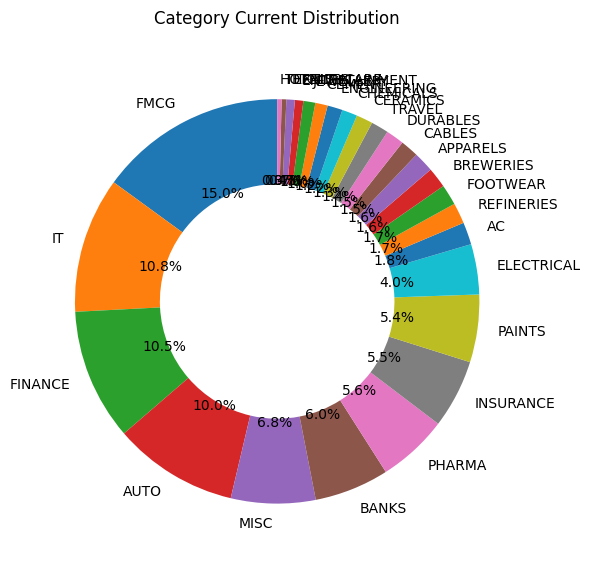

,Current
Category,
FMCG,2413608.0
IT,1747028.0
FINANCE,1692931.0
AUTO,1608462.0
MISC,1087730.0
BANKS,961857.0
PHARMA,906719.0
INSURANCE,883868.0
PAINTS,870767.0


In [5]:
# 4. Portfolio analysis

df_portfolio, portfolio_summary = qv.portfolio(
    market_data,
    portfolio_data=portfolio_data,
    eod=EOD_RUN,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)

qv.display_dataframe(
    df_portfolio,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="FTT Amt",
    ascending=True,
)

qv.display_run_summary(portfolio_summary)

qv.display_portfolio_category_chart(
    df_portfolio,
    category_column="Category",
    value_column="Current",
    title="Category Current Distribution",
)


In [6]:
# 5. Decision layer

In [7]:
df_prospects_actions = qv.prospect_actions(
    df_prospects,
    top_n=10,
)

qv.display_dataframe(
    df_prospects_actions,
    columns=PROSPECT_DISPLAY_COLUMNS,
    sort_by="CumlRnk",
    ascending=True,
)

,Symbol,FTT,Dev%_200,Dev%_PE,Spread%,Conviction,Cyclical,RSI_14,RSP,FTT%,ATH%,Gained%,CumlRnk,ROE%/PE,Criteria,Strategy,Category,InFolio
0,INFY,1972.00,-11.68,-38.91,16.11,X-LC,NC,57.0,74.31,69.66,63.56,17.96,1,2.0,X40,NTT,IT,DM
1,TCS,4230.71,-9.77,-42.64,15.01,X-LC,NC,52.0,83.68,80.27,80.27,19.02,2,3.0,X40,ATH,IT,DM
2,TMPV,600.00,-1.77,-82.76,4.48,X-LC,DC,55.0,59.03,72.54,228.53,18.38,3,47.3,XY24,NTT,AUTO,DM
3,HINDUNILVR,2922.00,-8.03,-40.89,6.25,X-LC,NC,42.0,36.81,41.52,40.93,2.08,4,1.0,XY25,NTT,FMCG,DM
4,HCLTECH,1853.42,-0.79,-11.33,12.94,X-LC,NC,69.0,92.01,36.17,36.17,32.95,5,1.1,X40,ATH,IT,DM
5,ITC,452.00,-13.08,-29.12,11.00,X-LC,NC,37.0,46.18,63.53,67.85,0.31,6,1.7,X40,NTT,FMCG,DM
6,RELIANCE,1952.00,-6.37,-6.74,7.09,X-LC,SC,51.0,55.21,48.80,20.82,4.21,7,0.4,XY25,BTT,REFINERIES,DM+SV
7,M&M,3762.88,2.38,-7.36,4.53,X-LC,DC,58.0,83.33,10.53,10.53,17.36,8,0.9,X40N,ATH,AUTO,DM
8,VBL,669.42,-7.81,-27.66,7.46,X-LC,NC,37.0,19.10,53.52,53.52,14.47,9,0.4,X40N,ATH,FMCG,DM
9,HDFCBANK,1073.00,-14.45,-28.50,12.03,X-LC,NC,33.0,6.25,47.72,37.18,0.93,10,1.0,X40,BTT,BANKS,DM+SV


In [8]:
df_portfolio_actions = qv.portfolio_actions(
    df_portfolio,
)


qv.display_dataframe(
    df_portfolio_actions,
    sort_by="CurrAlloc%",
    ascending=False,
)


,Symbol,AvgCost,FTT,FTT Amt,Dev%_PE,Spread%,Conviction,RSI_14,RSP,Shares,...,Strategy,Dev%_200,Risk Ind,Gained%,LatestQtr,StarStock,CumlRnk,Category,MBQ,Action
77,TMPV,420.31,600.00,249868.0,-82.76,4.69,X-LC,55.0,62.50,990,...,NTT,-2.08,-37.0,18.33,1.0,1.0,4.0,AUTO,XY24/X5K/X40N,EXIT_TARGET
49,JIOFIN,288.64,387.00,166139.0,-30.41,6.99,X-LC,61.0,85.23,1290,...,BTT,-0.69,-22.0,15.48,0.0,0.0,34.0,FINANCE,XY24/X40N,EXIT_TARGET
75,TCS,3406.42,4230.71,256183.0,-42.64,15.13,X-LC,52.0,87.50,136,...,ATH,-9.90,-62.0,19.03,1.0,1.0,2.0,IT,X40/X5K,EXIT_TARGET
70,STARHEALTH,516.77,761.00,98736.0,-1.10,16.98,H-SC,48.0,37.50,544,...,NTT,15.44,24.0,36.30,0.0,0.0,173.0,INSURANCE,XY24,EXIT_TARGET
84,VBL,493.47,669.42,166309.0,-27.66,7.72,X-LC,36.0,23.86,713,...,ATH,-7.79,-22.0,14.49,0.0,0.0,13.0,FMCG,X40N,EXIT_TARGET
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,COFFEEDAY,59.14,80.00,97247.0,NaN,4.73,L-nan,37.0,18.18,1920,...,NTT,-8.28,-18.0,38.97,0.0,0.0,266.0,HOTELS,XR,EXIT_TARGET
65,ROUTE,1317.49,2199.37,170252.0,NaN,5.52,H-nan,40.0,10.23,101,...,ATH,-9.72,-20.0,24.51,0.0,0.0,141.0,IT,SR,EXIT_TARGET
60,RAJOOENG,102.50,143.10,92852.0,NaN,17.33,H-nan,39.0,52.27,1000,...,ATH,-20.24,-16.0,7.65,0.0,0.0,136.0,MISC,AR,EXIT_TARGET
21,DEN,52.79,75.00,76094.0,NaN,5.83,M-nan,46.0,15.91,1600,...,NTT,-5.38,-13.0,19.41,0.0,0.0,235.0,ENTERTAINMENT,AR,EXIT_TARGET


## End of run

Calculations remain in the engine; notebook cells only orchestrate and present the results. The same structured outputs can later feed an API/Web UI.